<a href="https://colab.research.google.com/github/Wajid0005/CAMPUS-X-notebooks/blob/main/Copy_of_session_20_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [9]:
# import like this
items_path = "/content/items.csv"
q1_path = "https://drive.google.com/uc?export=download&id=17Tca-FYOu-qMpAaJBUuC2E1Ex3jCMpFg"
q2_path = "https://drive.google.com/uc?export=download&id=1pIBukQRAJi5ksNR5lNj0qslIbrlS_Bzf"
q3_path = "https://drive.google.com/uc?export=download&id=19d3AsHDuTj5ZiH-HthdfLmEBWF4T-Oyd"

q1 = pd.read_csv(q1_path)
q2 = pd.read_csv(q2_path)
q3 = pd.read_csv(q3_path)

items = pd.read_csv(items_path)

###`Q:1-5`
1. You are given three quater files, your job is to append these three files and make a single dataframe.
2. Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
4. Find out items which has made most revenue in each quarter.
5. Find out avg order price of each quarter.

***Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.***

In [10]:
#1 #2
all_quarters = pd.concat([q1,q2,q3])
all_quarters.shape

(4622, 5)

In [11]:
#2
#1 #2
all_quarters_id = pd.concat([q1,q2,q3], keys= ['Q-1', 'Q-2', 'Q-3']).reset_index(level=0)
all_quarters_id.rename(columns={'level_0': 'quarter'}, inplace=True )


In [12]:
items

,item_id,item_name
0,0,Chips and Fresh Tomato Salsa
1,1,Izze
2,2,Nantucket Nectar
3,3,Chips and Tomatillo-Green Chili Salsa
4,4,Chicken Bowl
5,5,Side of Chips
6,6,Steak Burrito
7,7,Steak Soft Tacos
8,8,Chips and Guacamole
9,9,Chicken Crispy Tacos


In [13]:
#3
item_data = pd.merge(items,all_quarters, how ='inner', on = 'item_id')
item_data

,item_id,item_name,order_id,quantity,choice_description_id,item_price
0,0,Chips and Fresh Tomato Salsa,13,1,0,$2.39
1,0,Chips and Fresh Tomato Salsa,82,1,0,$2.95
2,0,Chips and Fresh Tomato Salsa,104,1,0,$2.95
3,0,Chips and Fresh Tomato Salsa,142,1,0,$2.39
4,0,Chips and Fresh Tomato Salsa,149,1,0,$2.95
...,...,...,...,...,...,...
4617,48,Veggie Salad,1094,1,755,$8.49
4618,48,Veggie Salad,1192,1,149,$8.49
4619,48,Veggie Salad,1263,1,306,$8.49
4620,48,Veggie Salad,1395,1,755,$8.49


In [14]:
#3
item_data.groupby('order_id')['quantity'].value_counts().sort_values(ascending=False).head()

,,count
order_id,quantity,
926,1,23
1483,1,14
205,1,12
691,1,11
491,1,10


In [15]:
item_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   item_id                4622 non-null   object
 1   item_name              4622 non-null   object
 2   order_id               4622 non-null   object
 3   quantity               4622 non-null   object
 4   choice_description_id  4622 non-null   object
 5   item_price             4622 non-null   object
dtypes: object(6)
memory usage: 216.8+ KB


In [16]:
#4
item_summary = item_data.groupby('item_name').agg(
    total_quantity=('quantity', 'sum'),
    item_price=('item_price', 'mean'),
    total_revenue=('Revenue', 'sum')
).sort_values(by='total_quantity', ascending=False)

display(item_summary.head())

KeyError: "Column(s) ['Revenue'] do not exist"

In [ ]:
new_item_data['item_price'] = new_item_data['item_price'].astype(str).str.replace('$', '').astype(float)
new_item_data['revenue'] = (new_item_data['quantity'] * new_item_data['item_price']).astype(float)
new_item_data

In [ ]:
#5
# Re-merging to ensure new_item_data is up-to-date with 'quarter' and 'item_id' merges.
# Then ensuring item_price is numerical before calculating the mean.
new_item_data = pd.merge(items, all_quarters_id, how='inner', on='item_id')

# Ensure item_price is converted to numeric (float) before calculating mean
new_item_data['item_price'] = new_item_data['item_price'].astype(str).str.replace('$', '', regex=False).astype(float)

# Now calculate the average order price of each quarter
avg_order_price_per_quarter = new_item_data.groupby('quarter')['item_price'].mean()
print("Average order price per quarter:")
avg_order_price_per_quarter

###`Q-6` From the IPL wala dataset you have to find the Purple cap holder each season.

*Note: Bowler with most no wickets in a season gets purple cap. If more than one bowler have same no of wickets in the season, one with least ecomnomy among them is purple cap holder.*

Bowler's Economy = runs-conceded per six balls

In [19]:
ipl_ball = pd.read_csv("/content/IPL_Ball_by_Ball_2008_2022.csv")
ipl_ball.sample()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
21445,1254103,1,19,1,R Parag,HV Patel,CH Morris,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [18]:
ipl_matches = pd.read_csv("/content/IPL_Matches_2008_2022 (1).csv")
ipl_matches.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [46]:
bowled_df
ipl_deliveries = pd.read_csv("/content/ipl_deliveries - ipl_deliveries.csv")

In [20]:
ipl_ball = pd.read_csv("/content/IPL_Ball_by_Ball_2008_2022.csv")
bowled_df = ipl_ball[ipl_ball.kind == 'bowled']


In [ ]:
data.columns

In [22]:
data = pd.merge(bowled_df,ipl_matches,how='inner',on='ID')
data.groupby('Season')['bowler'].value_counts().sort_values(ascending = False).head(10)


Season   bowler     
2011     SL Malinga     16
2015     MA Starc       10
2014     SP Narine      10
2009     SL Malinga      9
2009/10  SL Malinga      8
2022     Umran Malik     8
2012     M Morkel        8
2013     DW Steyn        8
         JP Faulkner     8
2020/21  JJ Bumrah       8
Name: count, dtype: int64

###`Q-7:` Best bowler in death overs.
*Note: Have taken most no of wickets in case of tie with least economy*

Death Overs - [16-20]

In [23]:
ipl_deliveries = pd.read_csv("/content/IPL_Ball_by_Ball_2008_2022.csv")
ipl_ball.head(3)


,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals


In [24]:
ipl_matches.head(4)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma


In [36]:
ipl_data = pd.merge(ipl_ball,ipl_matches,how='inner',on='ID')
ipl_data.head(2)
temp = ipl_data[(ipl_data['overs'] > 15 )& (ipl_data['kind'] == 'bowled')]

In [44]:
wickets_per_bowler_death_overs = temp.groupby('bowler')['isWicketDelivery'].sum()
wickets_per_bowler_death_overs.sort_values(ascending=False).head(10)


,isWicketDelivery
bowler,
SL Malinga,31
B Kumar,19
CH Morris,17
JJ Bumrah,16
Mohammed Shami,16
RP Singh,15
DW Steyn,14
TA Boult,13
DJ Bravo,13


###`Q-8` Batsman record season wise

Make a function which takes a input `batsman_name` and it returns a dataframe.
Columns of the data frame are - `['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']`.
* In result make `Season` column as index.

* Avg - total_runs/ no of time got out. - player_out column will help.
* StrikeRate -(total_runs/ balls faced) * 100- wides are not included in batsman ball faced counts. No balls are included. -> Extra_type column will help
* Batsman Can score runs on No Balls.
* Batsman can get out on No Ball or Wides. And even while being on non-striker. Keep these things in mind before masking.

In [45]:
ipl_data.columns

Index(['ID', 'innings', 'overs', 'ballnumber', 'batter', 'bowler',
       'non-striker', 'extra_type', 'batsman_run', 'extras_run', 'total_run',
       'non_boundary', 'isWicketDelivery', 'player_out', 'kind',
       'fielders_involved', 'BattingTeam', 'City', 'Date', 'Season',
       'MatchNumber', 'Team1', 'Team2', 'Venue', 'TossWinner', 'TossDecision',
       'SuperOver', 'WinningTeam', 'WonBy', 'Margin', 'method',
       'Player_of_Match', 'Team1Players', 'Team2Players', 'Umpire1',
       'Umpire2'],
      dtype='object')

In [58]:
def batsman_record(batsman_name):
  total_runs = ipl_data[ipl_data['batter'] == batsman_name]['batsman_run'].sum()
  avg  = total_runs / ipl_data[(ipl_data['player_out'] == batsman_name)].shape[0]
  no_of_balls = ipl_data[(ipl_data['batter'] == batsman_name) & (ipl_data['extra_type'] != 'wides' )]['ballnumber'].count()
  strike_rate = (total_runs / no_of_balls) * 100
  highest_score = ipl_data[ipl_data['batter'] == batsman_name].groupby(['ID','innings'])['batsman_run'].sum().max()
  print(f"{batsman_name} scored total {total_runs} runs,\n his AVG is:{avg:.2f},\n his strike_rate:{strike_rate:.2f}\n & his higest score is:{highest_score}")

In [53]:
(ipl_data.player_out == 'MS Dhoni').sum()

np.int64(127)

In [55]:
ipl_data.extra_type.unique()

array([nan, 'legbyes', 'wides', 'byes', 'noballs', 'penalty'],
      dtype=object)

In [59]:
batsman_record('MS Dhoni')

MS Dhoni scored total 4978 runs,
 his AVG is:39.20,
 his strike_rate:135.20
 & his higest score is:84


In [65]:
batsman_record('YBK Jaiswal')

YBK Jaiswal scored total 547 runs,
 his AVG is:23.78,
 his strike_rate:134.73
 & his higest score is:68


In [63]:
ipl_data.batter.head()

,batter
0,YBK Jaiswal
1,YBK Jaiswal
2,JC Buttler
3,YBK Jaiswal
4,YBK Jaiswal


###`Q-9` Using both dataset, make a dataframe as described below

Data Frame columns-> `['PlayerOfThematch', 'BattingFigure', 'BowlingFigure']`

* BattingFigure->`<runs>/<balls>`
* BowlingFigure->`<wicket>/<runs-conceded>`

DataFrame should have one record for each match.

Say 'V Kohli' got POM award then in dataset include his batting figure of that match. Say he scored 112runs in 76 balls. And he hasn't bowled so Bowling Figure will be NaN
```
PlayerOfThematch BattingFigure BowlingFigure
V Kohli          112/76         nan  

```


In [ ]:
# code here

## **Questions Based on Iris Dataset**

- **Sepal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **SepalLengthCm:** Sepal length of flowers in cm
    - **SepalWidthCm:** Sepal width of flowers in cm

- **Petal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **PetalLengthCm:** Petal length of flowers in cm
    - **PetalWidthCm:** Petal width of flowers in cm

- **Iris Virginica:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Versicolor:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Setosa:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv
    - **Unnamed 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

In [112]:
import pandas as pd
sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv")
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv")

virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv")
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv")
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv")


### `Q-9:` Plot a bar chart of the average Sepal Length  of Virginica and average Petal length of Setosa flower.

In [123]:
versicolor

,Unnamed: 0,Id,Species
0,50,51,Iris-versicolor
1,51,52,Iris-versicolor
2,52,53,Iris-versicolor
3,53,54,Iris-versicolor
4,54,55,Iris-versicolor
5,55,56,Iris-versicolor
6,56,57,Iris-versicolor
7,57,58,Iris-versicolor
8,58,59,Iris-versicolor
9,59,60,Iris-versicolor


In [127]:
data_verg_seto = pd.concat([setosa, versicolor,virginica])
data_verg_seto.drop('Unnamed: 0', axis=1, inplace = True)
data_pet_sep = pd.concat([petal_all, sepal_all])
data_verg_seto
temp = pd.merge(data_verg_seto,data_pet_sep,how='inner',on='Id')
temp.drop('Unnamed: 0', axis=1, inplace = True)
temp['SepalLengthCm'].fillna(method = 'bfill', inplace = True)
temp['SepalWidthCm'].fillna(method = 'bfill', inplace = True)
temp.dropna(inplace = True)
temp


/tmp/ipykernel_315/1270165069.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp['SepalLengthCm'].fillna(method = 'bfill', inplace = True)
/tmp/ipykernel_315/1270165069.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp['SepalLengthCm'].fillna(method = 'bfill', inplace = True)
/tmp/ipykernel_315/1270165069.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inp

,Id,Species,PetalLengthCm,PetalWidthCm,SepalLengthCm,SepalWidthCm
0,1,Iris-setosa,1.4,0.2,5.1,3.5
2,2,Iris-setosa,1.4,0.2,4.9,3.0
4,3,Iris-setosa,1.3,0.2,4.7,3.2
6,4,Iris-setosa,1.5,0.2,4.6,3.1
8,5,Iris-setosa,1.4,0.2,5.0,3.6
...,...,...,...,...,...,...
290,146,Iris-virginica,5.2,2.3,6.7,3.0
292,147,Iris-virginica,5.0,1.9,6.3,2.5
294,148,Iris-virginica,5.2,2.0,6.5,3.0
296,149,Iris-virginica,5.4,2.3,6.2,3.4


In [128]:
temp_avg_spl_vir = temp.groupby('Species')['SepalLengthCm'].mean()
temp_avg_ptl_seto = temp.groupby('Species')['PetalLengthCm'].mean()
temp_avg_ptl_seto

,PetalLengthCm
Species,
Iris-setosa,1.464
Iris-versicolor,4.260
Iris-virginica,5.552


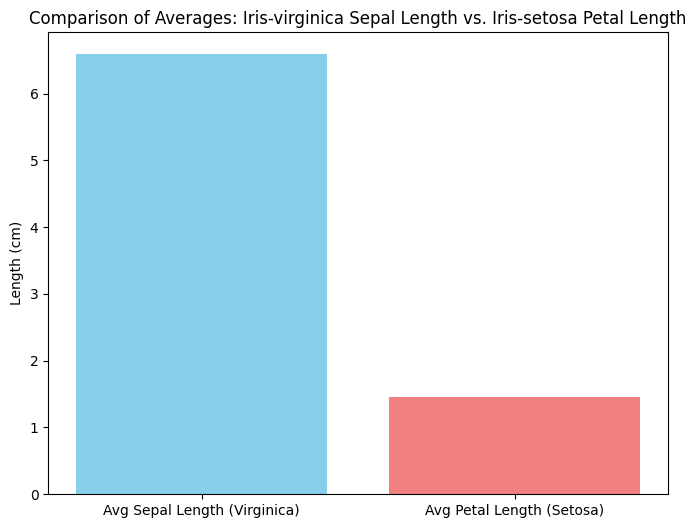

In [129]:
import matplotlib.pyplot as plt

# Extract the specific average values requested
avg_sepal_virginica = temp_avg_spl_vir['Iris-virginica']
avg_petal_setosa = temp_avg_ptl_seto['Iris-setosa']

# Prepare data for plotting
labels = ['Avg Sepal Length (Virginica)', 'Avg Petal Length (Setosa)']
values = [avg_sepal_virginica, avg_petal_setosa]

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(labels, values, color=['skyblue', 'lightcoral'])
plt.ylabel('Length (cm)')
plt.title('Comparison of Averages: Iris-virginica Sepal Length vs. Iris-setosa Petal Length')
plt.show()

### `Q-10:` Create the complete dataset by uisng the below datasets:
- virginica
- versicolor
- setosa
- sepal all
- petal all

This dataset should have these below column names in order:
1. Id
2. Species
3. SepalLengthCm
4. SepalWidthCm
5. PetalLengthCm
6. PetalWidthCm

Also, the dataset should be shuffled means the `Id` column should not be in increasing or decreasing order. So, make a dataset which has the shuffled Id column. You can use `DataFrame.sample()` method to shuffle.

In [132]:
temp.sample(10)

,Id,Species,PetalLengthCm,PetalWidthCm,SepalLengthCm,SepalWidthCm
212,107,Iris-virginica,4.5,1.7,4.9,2.5
148,75,Iris-versicolor,4.3,1.3,6.4,2.9
70,36,Iris-setosa,1.2,0.2,5.0,3.2
54,28,Iris-setosa,1.5,0.2,5.2,3.5
258,130,Iris-virginica,5.8,1.6,7.2,3.0
14,8,Iris-setosa,1.5,0.2,5.0,3.4
256,129,Iris-virginica,5.6,2.1,6.4,2.8
154,78,Iris-versicolor,5.0,1.7,6.7,3.0
250,126,Iris-virginica,6.0,1.8,7.2,3.2
280,141,Iris-virginica,5.6,2.4,6.7,3.1


### `Q-11:` Find out the maximum and minimum sepal width and petal width of Setosa and Versicolor. To do this:
- First create a dataset with merging the required datasets
- After that, use `groupby` to create groups based on the "Species" column.
- Then find out which are asked in this question.


The output should be like this:
```bash
Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4

**************************************************

Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4

**************************************************
```

In [134]:
temp.groupby('Species').agg({
    'SepalWidthCm': ['min', 'max'],
    'PetalWidthCm': ['min', 'max']
})

SepalWidthCm      PetalWidthCm     
                         min  max          min  max
Species                                            
Iris-setosa              2.3  4.4          0.1  0.6
Iris-versicolor          2.0  3.4          1.0  1.8
Iris-virginica           2.2  3.8          1.4  2.5